# Phase 3: Survival Score Modeling

In this phase, we quantify 'Survival' by combining proximity to essential resources with risks like drug crime hotspots.

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.neighbors import BallTree
import matplotlib.pyplot as plt

PROCESSED_DIR = '../data/processed/'

def load_processed(filename):
    return pd.read_csv(os.path.join(PROCESSED_DIR, filename))

fountains = load_processed('drinking_fountains_cleaned.csv')
centers = load_processed('drop_in_centers_cleaned.csv')
crime = load_processed('drug_crime_cleaned.csv')
link = load_processed('link_nyc_cleaned.csv')
toilets = load_processed('public_toilets_cleaned.csv')

print("Data loaded.")

Data loaded.


## 1. Grid Definition
We divide NYC into a grid to calculate local scores.

In [2]:
lat_min, lat_max = 40.49, 40.92
lon_min, lon_max = -74.26, -73.69
grid_size = 50

lats = np.linspace(lat_min, lat_max, grid_size)
lons = np.linspace(lon_min, lon_max, grid_size)
grid_points = np.array(np.meshgrid(lats, lons)).T.reshape(-1, 2)
grid_df = pd.DataFrame(grid_points, columns=['latitude', 'longitude'])

## 2. Proximity & Risk Calculation
Using BallTree for efficient spatial lookups.

In [3]:
pos_resources = pd.concat([
    fountains[['latitude', 'longitude']], 
    centers[['latitude', 'longitude']], 
    link[['latitude', 'longitude']],
    toilets[['latitude', 'longitude']]
]).dropna()

pos_tree = BallTree(np.deg2rad(pos_resources), metric='haversine')
neg_tree = BallTree(np.deg2rad(crime[['latitude', 'longitude']].dropna()), metric='haversine')

grid_rad = np.deg2rad(grid_df[['latitude', 'longitude']])
dist_pos, _ = pos_tree.query(grid_rad, k=1)
crime_count = neg_tree.query_radius(grid_rad, r=0.00008, count_only=True)

grid_df['pos_score'] = 1 / (dist_pos + 0.001)
grid_df['neg_score'] = crime_count

## 3. Final Score Synthesis
Normalizing and weighting factors.

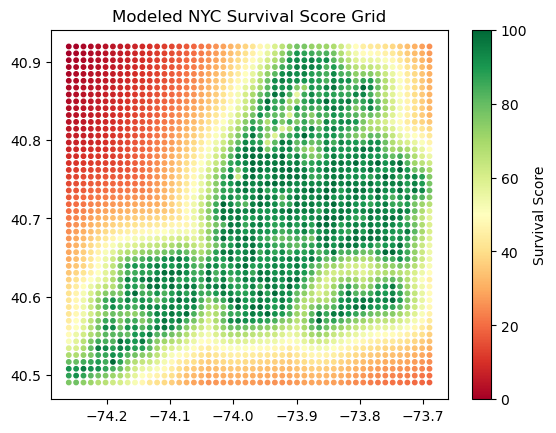

In [4]:
def min_max(x):
    return (x - x.min()) / (x.max() - x.min())

grid_df['survival_score'] = (min_max(grid_df['pos_score']) * 0.7) - (min_max(grid_df['neg_score']) * 0.3)
grid_df['survival_score'] = min_max(grid_df['survival_score']) * 100

plt.scatter(grid_df['longitude'], grid_df['latitude'], c=grid_df['survival_score'], cmap='RdYlGn', s=10)
plt.colorbar(label='Survival Score')
plt.title('Modeled NYC Survival Score Grid')
plt.show()